In [1]:
import torch
from torchvision import models, transforms
from collections import OrderedDict
from torch.utils.data import DataLoader, Subset
import pandas as pd
import numpy as np
import os
import re
from PIL import Image

# Cell 0: load a ResNet-50 multilabel model checkpoint

def load_resnet50_multilabel(checkpoint_path, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(checkpoint_path, map_location=device)

    # unpack common checkpoint formats
    if isinstance(ckpt, dict):
        if 'state_dict' in ckpt:
            state_dict = ckpt['state_dict']
        elif 'model_state_dict' in ckpt:
            state_dict = ckpt['model_state_dict']
        else:
            # assume the dict is the state_dict itself
            state_dict = ckpt
    elif isinstance(ckpt, torch.nn.Module):
        return ckpt.to(device).eval()

    # remove possible "module." prefixes from DataParallel
    new_state = OrderedDict()
    for k, v in state_dict.items():
        new_state[k.replace("module.", "")] = v
    state_dict = new_state

    # infer output size from fc.weight or linear layer keys
    out_features = None
    for k in state_dict.keys():
        if re.search(r'\bfc\.weight$', k):
            out_features = state_dict[k].size(0)
            break
        # some checkpoints might name the head differently
        m = re.search(r'\b(?:classifier|head)\.weight$', k)
        if m:
            out_features = state_dict[k].size(0)
            break
    if out_features is None:
        # fallback: try to find any final linear weight with 2D tensor and use its first dim
        for k, v in state_dict.items():
            if v.ndim == 2:
                out_features = v.size(0)
                break

    # build ResNet50 and replace final layer
    model = models.resnet50(pretrained=False)
    if out_features is None:
        raise RuntimeError("Could not infer output features from checkpoint. Inspect checkpoint keys.")
    model.fc = torch.nn.Linear(model.fc.in_features, out_features)

    model.load_state_dict(state_dict, strict=False)
    model = model.to(device).eval()
    return model

# usage
model_path = "best_resnet50_multilabel.pth"
model = load_resnet50_multilabel(model_path)

/work/cssema416/202610/21/env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/work/cssema416/202610/21/env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [2]:
px = 200
img_size = (px,px)
imgs = 100000

In [3]:
class MultiLabelImageDatasetBinary(torch.utils.data.Dataset):
    """
    CSV format:
      - one column contains image filename/path (default 'Image Number' or set path_col)
      - other columns are label columns containing 0/1 or values like 'yes','no','True','False'
    Returns: (image_tensor, multi_hot_tensor)
    """
    def __init__(self, csv_file, img_dir=None, transform=None, path_col='Image Number', label_cols=None):
        self.df = pd.read_csv(csv_file, dtype=str, nrows=imgs)
        self.img_dir = img_dir
        self.transform = transform
        self.path_col = path_col

        # infer label columns if not provided: all columns except path_col
        if label_cols is None:
            label_cols = [c for c in self.df.columns if c != self.path_col]
        self.label_cols = label_cols

        # normalize label values to 0/1
        def to_binary(x):
            if pd.isna(x): 
                return 0
            s = str(x).strip().lower()
            if s in ('1','true','t','yes','y','on'):
                return 1
            if s in ('0','false','f','no','n','off'):
                return 0
            # try numeric
            try:
                return 1 if float(s) != 0 else 0
            except:
                return 0

        labels_array = self.df[self.label_cols].applymap(to_binary).astype(np.int64).values
        self.labels = labels_array  # shape (N, n_labels)

        # file paths
        self.paths = self.df[self.path_col].astype(str).tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx] + '.jpg'
        if self.img_dir:
            p = os.path.join(self.img_dir, p)
        img = Image.open(p).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.from_numpy(self.labels[idx].astype(np.float32))
        return img, label

# Replace ImageFolder usage and plotting setup
csv_file = './image_labels.csv'     # <-- set this to your CSV
img_base_dir = './dataset'     # optional, set to None if CSV contains full paths
path_col = 'Image Number'                 # update if different

batch_size = 25
load_image = transforms.Compose([
    transforms.Resize((px, px)),
    transforms.ToTensor(),
])

dataset = MultiLabelImageDatasetBinary(csv_file, img_dir=img_base_dir, transform=load_image, path_col=path_col)
print("Number of classes:", len(dataset.label_cols))
print("Class names:", dataset.label_cols)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
data_iter = iter(dataloader)
# get a batch
images, labels = next(iter(dataloader))   # images: (B,C,H,W), labels: (B,n_classes)

# small helper to build readable titles for plotting
def labels_to_title(label_row, label_names):
    idxs = [label_names[i] for i,v in enumerate(label_row) if v]
    return ",".join(idxs) if idxs else "none"

label_names = dataset.label_cols

/tmp/ipykernel_1475515/167526225.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels_array = self.df[self.label_cols].applymap(to_binary).astype(np.int64).values


Number of classes: 10
Class names: ['Goal', 'Start/Restart', 'Joy', 'Yellow Card', 'Red Card', 'Ball', 'Stadium View', 'Referee', 'Penalty Kick', 'Free Kick']


/tmp/ipykernel_1475515/167526225.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels_array = self.df[self.label_cols].applymap(to_binary).astype(np.int64).values


Goal: accuracy=95.25%  (positives=4804/20000)
Start/Restart: accuracy=99.79%  (positives=104/20000)
Joy: accuracy=98.97%  (positives=261/20000)
Yellow Card: accuracy=99.71%  (positives=113/20000)
Red Card: accuracy=99.94%  (positives=14/20000)
Ball: accuracy=83.12%  (positives=9611/20000)
Stadium View: accuracy=97.91%  (positives=844/20000)
Referee: accuracy=83.57%  (positives=7053/20000)
Penalty Kick: accuracy=99.69%  (positives=109/20000)
Free Kick: accuracy=98.04%  (positives=550/20000)


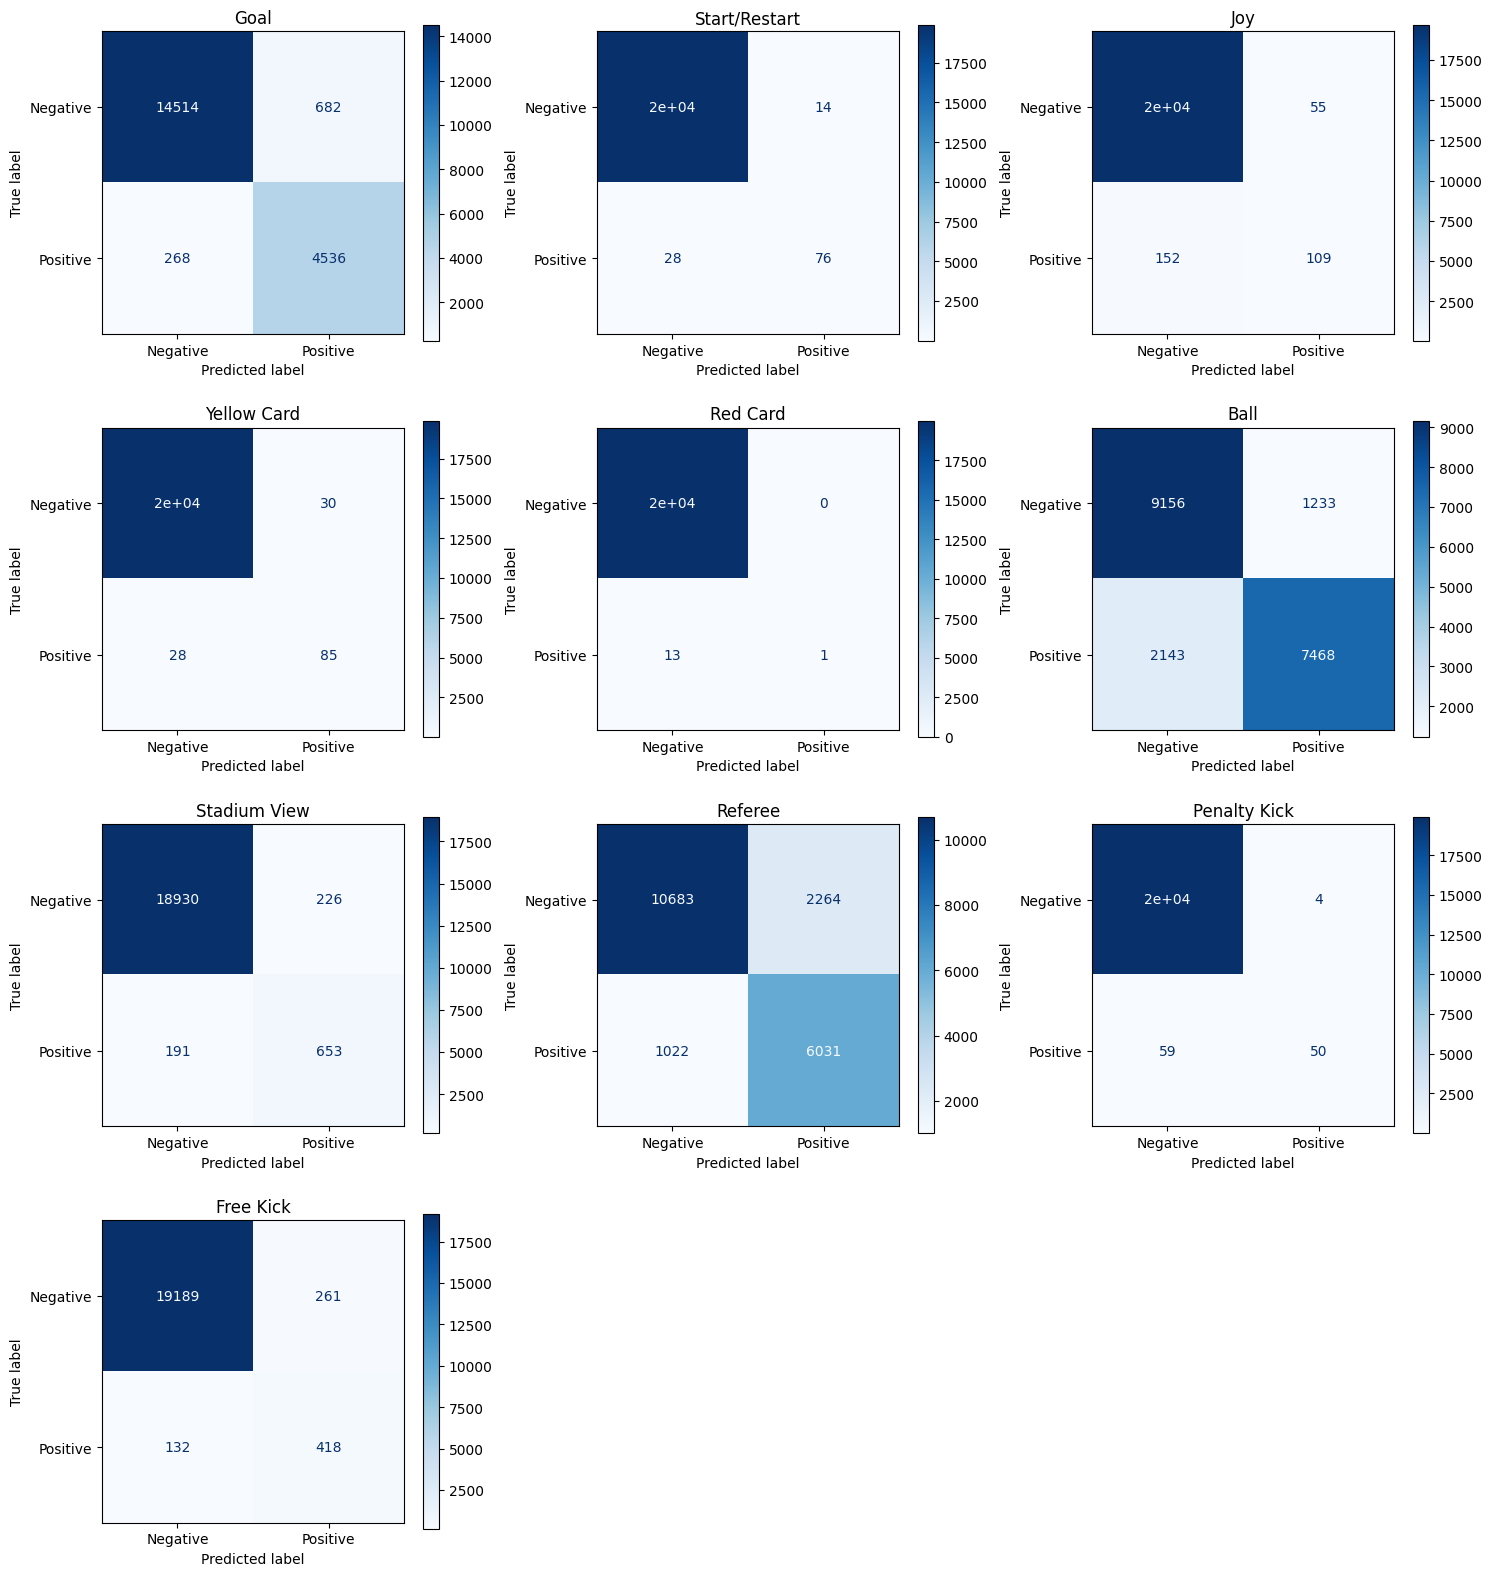

In [5]:
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def per_class_accuracy_from_loader(model, loader, label_names, device='cuda:0', threshold=0.5):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= threshold).astype(int)
            all_pred.append(preds)
            all_true.append(labels.numpy().astype(int))
    y_pred = np.vstack(all_pred)
    y_true = np.vstack(all_true)
    n_samples = y_true.shape[0]
    accs = ((y_pred == y_true).sum(axis=0) / n_samples) * 100.0
    # print results
    for i, name in enumerate(label_names):
        positives = int(y_true[:, i].sum())
        print(f"{name}: accuracy={accs[i]:.2f}%  (positives={positives}/{n_samples})")

    # For multilabel data, compute confusion matrix per label
    n_labels = y_true.shape[1]
    n_cols = min(3, n_labels)  # display up to 3 CMs per row
    n_rows = (n_labels + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_labels == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i in range(n_labels):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
        disp.plot(cmap=plt.cm.Blues, ax=axes[i])
        axes[i].set_title(f'{label_names[i]}', fontsize=12)
    
    # hide unused subplots
    for j in range(n_labels, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    return accs, y_true, y_pred

# Example: build the same validation loader used for training and compute per-class accuracy
# Adjust batch_size, val_frac and device as needed
batch_size = 32
val_frac = 0.2
device = 'cuda:0'     # or 'cpu'

# recreate dataset and split (must match how you split during training)
val_transform = transforms.Compose([
    transforms.Resize((px, px)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
ds_full = MultiLabelImageDatasetBinary(csv_file, img_dir=img_base_dir, transform=val_transform, path_col=path_col)
n = len(ds_full)
indices = list(range(n))
_, val_idx = train_test_split(indices, test_size=val_frac, random_state=0, shuffle=True)
val_set = Subset(ds_full, val_idx)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

accs, y_true, y_pred = per_class_accuracy_from_loader(model, val_loader, ds_full.label_cols, device=device, threshold=0.5)